## Task 1 — Descriptive Statistics

In [1]:
# =========================
# :package: IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import duckdb

sys.path.append(os.path.abspath(".."))
from src.database import get_connection
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import skew, kurtosis
from scipy.stats import probplot
from IPython.display import display
sns.set_style("whitegrid")

In [2]:
# =========================
#  LOAD DATA
# =========================
conn = duckdb.connect('../data/database/weather_daily.duckdb')
df = conn.execute("""
    SELECT *
    FROM analytics.weather_features_historical
""").df()

df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["dayofyear"] = df["date"].dt.dayofyear

print("Shape:", df.shape)

if df.empty:
    raise ValueError("Dataset is empty!")

Shape: (7308, 44)


In [3]:
df = conn.execute("""
    SELECT *
    FROM analytics.weather_features_historical
""").df()

df.columns

Index(['date', 'city', 'weathercode', 'temperature_2m_max',
       'temperature_2m_min', 'apparent_temperature_max',
       'apparent_temperature_min', 'precipitation_sum', 'precipitation_hours',
       'rain_sum', 'snowfall_sum', 'windspeed_10m_max', 'windgusts_10m_max',
       'winddirection_10m_dominant', 'weathercode_outlier',
       'temperature_2m_max_outlier', 'temperature_2m_min_outlier',
       'apparent_temperature_max_outlier', 'apparent_temperature_min_outlier',
       'precipitation_sum_outlier', 'precipitation_hours_outlier',
       'rain_sum_outlier', 'snowfall_sum_outlier', 'windspeed_10m_max_outlier',
       'windgusts_10m_max_outlier', 'winddirection_10m_dominant_outlier',
       'temp_mean', 'temp_range', 'precip_7d_avg', 'precip_30d_avg',
       'precip_lag_1', 'precip_lag_2', 'temp_7d_avg', 'temp_30d_avg',
       'temp_lag_1', 'temp_lag_2', 'month', 'quarter', 'day_of_year', 'season',
       'HDD', 'CDD'],
      dtype='str')

In [4]:
# =========================
# :bar_chart: 1. DESCRIPTIVE STATISTICS
# =========================

from scipy.stats import skew, kurtosis

num_cols = [
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "windspeed_10m_max",
    "temp_mean",
    "temp_range",
    "temp_7d_avg",
    "temp_30d_avg",
    "HDD",
    "CDD"
]

def skewness(x):
    return skew(x, nan_policy='omit')

def kurt(x):
    return kurtosis(x, nan_policy='omit')

def q25(x): 
    return x.quantile(0.25)

def q75(x): 
    return x.quantile(0.75)

city_stats = df.groupby("city")[num_cols].agg([
    "count", "mean", "std", "min",
    q25, "median", q75,
    "max", skewness, kurt
])

print(city_stats)

           temperature_2m_max                                               \
                        count       mean        std    min     q25  median   
city                                                                         
Baku                     1827  19.681719   9.334227 -1.000  11.625  18.850   
Ganja                    1827  19.555255   9.807095 -1.450  11.175  19.350   
Nakhchivan               1827  21.159496  11.460694 -4.900  11.100  21.350   
Shusha                   1827  13.261395   8.410205 -7.803   7.047  13.447   

                                                ...   CDD                      \
               q75     max  skewness      kurt  ... count      mean       std   
city                                            ...                             
Baku        27.750  40.050  0.108086 -1.087587  ...  1827  2.738848  3.977835   
Ganja       28.150  38.350  0.018556 -1.129220  ...  1827  2.467529  3.776692   
Nakhchivan  31.550  42.350 -0.070575 -1.223802  

In [5]:
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

In [6]:
# =========================
# 2. YEARLY SUMMARIES (FIXED)
# =========================
yearly = df.groupby(["city","year"]).agg({
    "temp_mean":"mean",
    "precipitation_sum":"sum",
    "windspeed_10m_max":"max"
}).reset_index()

display(yearly)

,city,year,temp_mean,precipitation_sum,windspeed_10m_max
0,Baku,2021,19.548878,127.400002,57.964470
1,Baku,2022,15.810205,274.999999,50.103413
2,Baku,2023,16.370959,254.399998,54.873730
3,Baku,2024,15.933880,417.699998,51.045160
4,Baku,2025,15.955000,353.100008,45.568806
5,Baku,2026,8.722107,268.300007,38.852074
6,Ganja,2021,18.685306,129.499996,37.303020
7,Ganja,2022,14.924041,226.100002,40.794525
8,Ganja,2023,15.104726,425.700000,42.694542
9,Ganja,2024,14.537568,477.599998,48.498560


In [7]:
# =========================
# 3. MONTHLY PROFILES
# =========================
monthly = df.groupby(["city","month"])[num_cols].agg(["mean","std"])

display(monthly)

temperature_2m_max           temperature_2m_min            \
                               mean       std               mean       std   
city       month                                                             
Baku       1               8.091613  2.825480           2.529032  2.419717   
           2               8.820213  4.689608           2.563475  3.135846   
           3              12.381613  4.416480           5.647097  3.069801   
           4              18.312667  4.341617          10.273000  2.426349   
           5              22.839744  4.598856          14.305769  2.524442   
           6              29.256333  3.486274          19.982667  1.855212   
           7              31.653548  3.349637          22.775161  1.667502   
           8              32.911290  2.973337          22.904194  1.867215   
           9              25.865333  4.039511          18.473000  2.621706   
           10             20.138065  3.547864          13.616129  2.960201   
           11             15.096000  3.242951           9.348333  2.781871   
           12             10.129032  2.727534           4.976774  2.630924   
Ganja      1               7.202903  3.611082          -0.400968  2.265728   
           2               8.610284  4.717818           0.781560  3.259286   
           3              13.171290  5.305214           4.112581  3.531480   
           4              19.848667  4.439012           9.382667  2.886139   
           5              23.732692  4.476976          13.438462  2.938103   
           6              29.487333  3.281288          18.640667  2.073841   
           7              32.358387  3.378541          21.167097  2.198394   
           8              32.850323  2.893283          21.172903  1.947761   
           9              25.330667  4.519279          16.234667  3.000134   
           10             18.943871  3.846129          10.767742  3.013372   
           11             14.127667  3.836375           6.250333  2.570767   
           12              8.324516  3.352622           1.604516  2.734272   
Nakhchivan 1               4.818387  3.015146          -3.516452  2.528263   
           2               8.709574  4.661043          -1.194326  3.329002   
           3              14.782903  4.907688           3.524839  3.660878   
           4              21.892333  4.199140           9.509000  3.052428   
           5              26.085256  4.562944          13.510577  2.793495   
           6              33.234667  2.971972          19.571333  2.089992   
           7              35.379355  3.159431          22.046774  2.176287   
           8              36.389677  2.520421          22.349677  1.681619   
           9              29.624667  4.476695          16.719667  3.217527   
           10             21.446452  4.431199          10.584194  3.116300   
           11             14.038000  3.588847           4.728667  2.800404   
           12              6.812903  2.818260          -0.830323  2.597736   
Shusha     1               3.197323  4.712523          -4.186871  3.580833   
           2               3.792390  5.639598          -3.634206  4.072554   
           3               7.127000  6.031402          -0.200097  4.085925   
           4              13.261333  4.263614           5.039000  3.006604   
           5              15.638346  4.138689           8.410462  2.976631   
           6              20.541667  2.832145          13.228667  2.107333   
           7              23.533129  3.232840          15.608613  2.154479   
           8              24.769903  2.862760          16.345065  1.934201   
           9              18.144000  4.441247          11.419000  3.000562   
           10             13.340871  4.061801           6.619903  3.037152   
           11             10.272667  4.308018           2.990667  3.213490   
           12              4.943452  4.009405          -1.500097  2.880179   

                 precipitation_sum    

In [8]:
# =========================
# 🌡️ EXTREME VALUES BY CITY
# =========================

num_cols = [
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "windspeed_10m_max",
    "temp_mean",
    "temp_range",
    "temp_7d_avg",
    "temp_30d_avg",
    "HDD",
    "CDD"
]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


# =========================
# 🔥 HOTTEST DAYS (by city)
# =========================
print("🔥 HOTTEST DAYS BY CITY")

for city in df["city"].unique():
    print(f"\n--- {city} ---")
    display(
        df[df["city"] == city]
        .nlargest(10, "temp_mean")[["date", "temp_mean"]]
    )


# =========================
# ❄️ COLDEST DAYS (by city)
# =========================
print("❄️ COLDEST DAYS BY CITY")

for city in df["city"].unique():
    print(f"\n--- {city} ---")
    display(
        df[df["city"] == city]
        .nsmallest(10, "temp_mean")[["date", "temp_mean"]]
    )


# =========================
# 🌧️ WETTEST DAYS (by city)
# =========================
print("🌧️ WETTEST DAYS BY CITY")

for city in df["city"].unique():
    print(f"\n--- {city} ---")
    display(
        df[df["city"] == city]
        .nlargest(10, "precipitation_sum")[["date", "precipitation_sum"]]
    )


# =========================
# 💨 WINDIEST DAYS (by city)
# =========================
print("💨 WINDIEST DAYS BY CITY")

for city in df["city"].unique():
    print(f"\n--- {city} ---")
    display(
        df[df["city"] == city]
        .nlargest(10, "windspeed_10m_max")[["date", "windspeed_10m_max"]]
    )

🔥 HOTTEST DAYS BY CITY

--- Baku ---


,date,temp_mean
100,2021-08-09 20:00:00,32.975
56,2021-06-26 20:00:00,32.425
102,2021-08-11 20:00:00,32.375
55,2021-06-25 20:00:00,31.975
1541,2025-07-20 20:00:00,31.875
828,2023-08-07 20:00:00,31.850
98,2021-08-07 20:00:00,31.775
103,2021-08-12 20:00:00,31.675
798,2023-07-08 20:00:00,31.625
1557,2025-08-05 20:00:00,31.500



--- Ganja ---


,date,temp_mean
1926,2021-08-08 20:00:00,31.850
1925,2021-08-07 20:00:00,31.500
2270,2022-07-18 20:00:00,31.450
2655,2023-08-07 20:00:00,31.100
1928,2021-08-10 20:00:00,31.000
2269,2022-07-17 20:00:00,30.925
3371,2025-07-23 20:00:00,30.900
2268,2022-07-16 20:00:00,30.775
3384,2025-08-05 20:00:00,30.775
3383,2025-08-04 20:00:00,30.675



--- Shusha ---


...

,date,windspeed_10m_max
2946,2024-05-24 20:00:00,48.498560
2792,2023-12-22 20:00:00,42.694542
2264,2022-07-12 20:00:00,40.794525
3368,2025-07-20 20:00:00,40.768310
2148,2022-03-18 20:00:00,40.091133
2172,2022-04-11 20:00:00,40.031290
2266,2022-07-14 20:00:00,39.860954
2299,2022-08-16 20:00:00,39.758410
3589,2026-02-26 20:00:00,39.495550
2149,2022-03-19 20:00:00,38.961580



--- Shusha ---


,date,windspeed_10m_max
4664,2024-02-05 20:00:00,37.196900
4620,2023-12-23 20:00:00,25.199997
3960,2022-03-03 20:00:00,22.596990
4877,2024-09-05 20:00:00,21.758419
4145,2022-09-04 20:00:00,21.542923
4327,2023-03-05 20:00:00,20.873790
3867,2021-11-30 20:00:00,20.808498
4055,2022-06-06 20:00:00,20.808498
4365,2023-04-12 20:00:00,20.808498
4722,2024-04-03 20:00:00,20.799152



--- Nakhchivan ---


,date,windspeed_10m_max
5864,2022-05-19 20:00:00,40.643345
6704,2024-09-05 20:00:00,39.966484
6300,2023-07-29 20:00:00,39.919440
6600,2024-05-24 20:00:00,39.096060
6179,2023-03-30 20:00:00,37.798286
5882,2022-06-06 20:00:00,37.690125
5550,2021-07-09 20:00:00,37.614403
5925,2022-07-19 20:00:00,37.221283
5569,2021-07-28 20:00:00,37.017033
5948,2022-08-11 20:00:00,37.008278


## Task 2 — Distribution Analysis

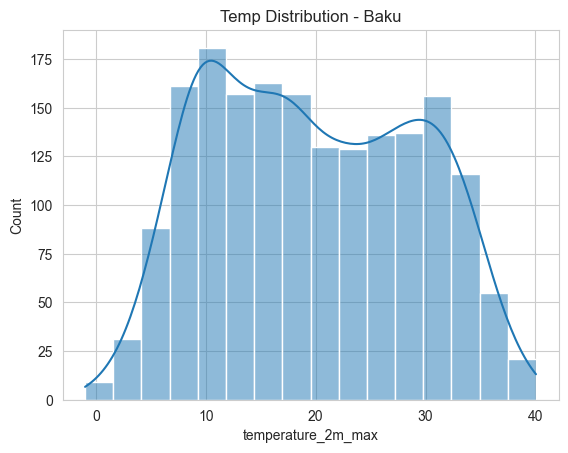

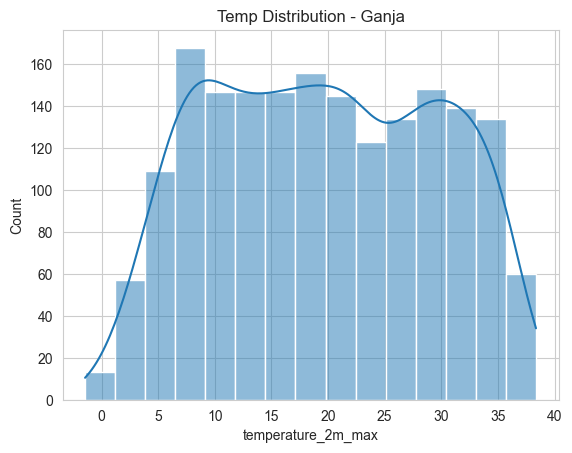

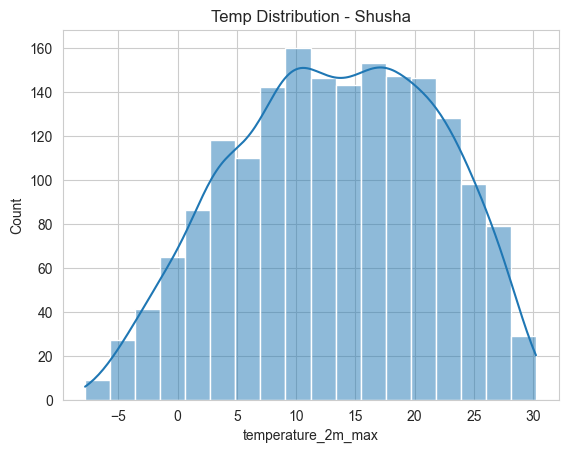

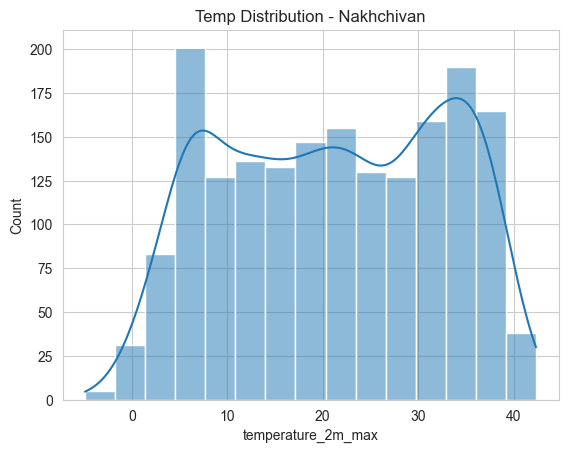

In [9]:
# =========================
# 5. DISTRIBUTIONS
# =========================
for city in df["city"].unique():
    sns.histplot(df[df["city"]==city]["temperature_2m_max"], kde=True)
    plt.title(f"Temp Distribution - {city}")
    plt.show()

* **Ganja:** The distribution is widely spread and **Multimodal**. It lacks a single, clear central peak, showing several "waves" between $10^\circ\text{C}$ and $35^\circ\text{C}$.
* **Baku:** Shows a prominent **Bimodal** (two-peak) structure. There is a high-frequency peak around $10^\circ\text{C}$ (winter/spring influence) and another near $32^\circ\text{C}$ (summer influence).
* **Shusha:** While more symmetrical than the others, it still exhibits a "flat-top" or plateau-like distribution between $10^\circ\text{C}$ and $20^\circ\text{C}$. It is the only city skewed towards the colder end of the spectrum.
* **Nakhchivan:** Displays the most extreme **Bimodal** behavior. Two very sharp, distinct peaks at $5^\circ\text{C}$ and $35^\circ\text{C}$ represent the harsh continental contrast between winter and summer.

#### Temperature Distribution Analysis: Cross-City Comparison

This report analyzes the maximum daily temperature distributions for four major cities: **Ganja, Baku, Shusha, and Nakhchivan**. The visualizations combine histograms with Kernel Density Estimation (KDE) to illustrate frequency and distribution patterns.

##### Ganja: Balanced Multimodal Distribution
* **Range:** Approximately -2°C to 38°C.
* **Pattern:** The distribution is relatively flat across the 10°C to 35°C range, with slight peaks near 8°C and 30°C. 
* **Insight:** This suggests a fairly even transition between seasons, with a high frequency of both mild and warm days.

##### Baku: Coastal Stability with a Cool-Peak
* **Range:** Approximately 0°C to 40°C.
* **Pattern:** Shows a distinct peak (mode) around **10°C**, indicating a high frequency of cool-to-mild days. There is a secondary peak near 32°C.
* **Insight:** The maritime influence likely keeps the distribution slightly more concentrated compared to the inland cities, though it still exhibits a bimodal (two-peak) summer/winter structure.

##### Shusha: High-Altitude Cool Distribution
* **Range:** Approximately -8°C to 30°C.
* **Pattern:** This is the only city in the set where the distribution is shifted significantly to the left (colder). The temperature rarely exceeds 30°C.
* **Insight:** The peak frequency occurs between **10°C and 20°C**. The "bell" shape is more pronounced here than in the other cities, though it still shows slight multi-modality.

##### Nakhchivan: Extreme Continental Variance
* **Range:** Approximately -5°C to 43°C.
* **Pattern:** Features the widest temperature range and the most aggressive bimodal structure. There are very sharp peaks at **5°C** and **35°C**.
* **Insight:** This reflects a classic continental climate with distinct, long-lasting cold winters and very hot summers, with fewer "middle-ground" transition days.

##### 2. Statistical Summary (Normality Check)

Across all four cities, the data **does not follow a Normal (Gaussian) Distribution**. 

* **Non-Normality:** A normal distribution would require a single central peak (mean) with symmetrical tapering. Instead, these plots show **Bimodal** or **Multimodal** patterns.
* **Reasoning:** In climate data, the presence of distinct seasons (Summer vs. Winter) naturally creates two different clusters of data points, preventing a single bell curve from forming when looking at full-year datasets.


In [10]:
from scipy.stats import skew, kurtosis

for city in df["city"].unique():
    data = df[df["city"]==city]["temp_mean"].dropna()
    
    print(city)
    print("Skew:", skew(data))
    print("Kurtosis:", kurtosis(data))
    print("-"*30)

Baku
Skew: 0.05834334295817273
Kurtosis: -1.1900334531250494
------------------------------
Ganja
Skew: 0.022230135117079712
Kurtosis: -1.1821176584464166
------------------------------
Shusha
Skew: -0.12438298119085403
Kurtosis: -0.8990905492699373
------------------------------
Nakhchivan
Skew: -0.06140921985845731
Kurtosis: -1.2367130779387177
------------------------------


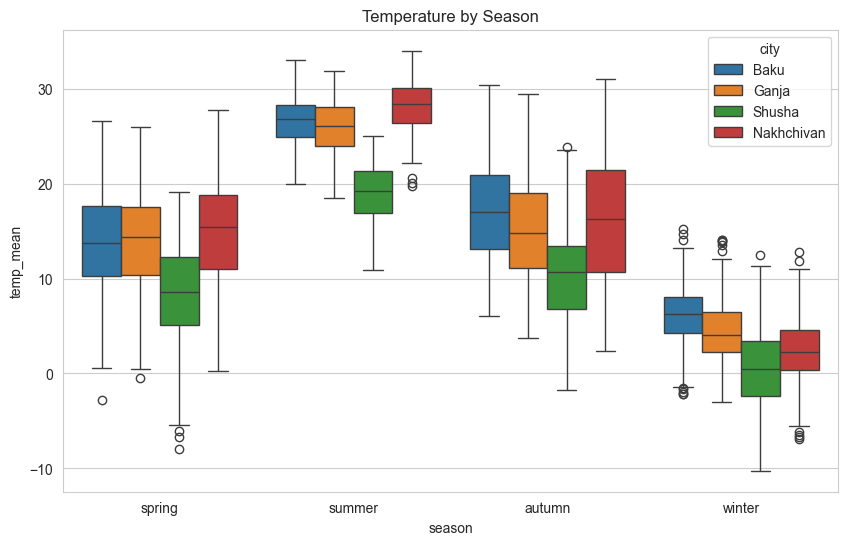

In [11]:
# =========================
#  6. BOX PLOT
# =========================
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="season", y="temp_mean", hue="city")
plt.title("Temperature by Season")
plt.show()


#### Summer: High Stability and Peak Heat
* **The Hottest City:** Nakhchivan consistently records the highest median temperatures, often reaching or exceeding $30^\circ\text{C}$.
* **Consistency:** Summer boxes are typically the "shortest" across all cities. This indicates low variance; once summer establishes itself, the heat remains relatively constant day-to-day.
* **Outliers:** Nakhchivan shows several low-temperature outliers, likely indicating rare, heavy storm events that temporarily break the heat.

#### Winter: The Coldest Variance
* **The Coldest City:** Shusha is clearly the coldest location, with its entire Interquartile Range (IQR) sitting significantly lower than the other three cities, often hovering near or below $0^\circ\text{C}$.
* **Extreme Events:** Winter exhibits the most frequent "downward" outliers, particularly in Baku and Nakhchivan, representing severe cold snaps.

#### Spring & Autumn: High Volatility
* **Volatility:** These transitional seasons show the "tallest" boxes and longest whiskers. This reflects high day-to-day temperature swings as the climate shifts between extremes.
* **Spring vs. Autumn:** Spring in Baku and Ganja tends to have a wider range than Autumn, suggesting that the "warming up" period is more erratic than the "cooling down" period.

# Seasonal Temperature Variance: Box Plot Analysis

This report examines the distribution of mean temperatures across four seasons (**Spring, Summer, Autumn, Winter**) for the cities of **Ganja, Baku, Shusha, and Nakhchivan**. The box plot allows for a clear comparison of medians, quartiles, and outliers.

#### 1. Key Seasonal Findings

#### Summer: The Season of Extremes
* **Highest Temperatures:** Nakhchivan (Red) clearly dominates the summer season with the highest median temperature, nearing 30°C.
* **Consistency:** Summer boxes are generally "shorter" (smaller Interquartile Range - IQR) for most cities, indicating that summer temperatures are consistently high with less day-to-day fluctuation compared to transitional seasons.
* **Outliers:** Nakhchivan shows several low-temperature outliers in summer, likely representing rare cold fronts or heavy rain events.

#### Winter: The Coldest Variance
* **Coldest City:** Shusha (Green) maintains the lowest median temperature, frequently dropping below 0°C. 
* **Outliers:** All cities show significant outliers in winter, particularly Baku and Nakhchivan, suggesting occasional "extreme" cold snaps that fall far below the typical seasonal range.

#### Spring and Autumn: The Transition Periods
* **High Variability:** The "whiskers" and boxes for Spring and Autumn are noticeably longer. This indicates high volatility as the weather transitions between the heat of summer and the cold of winter.
* **Baku vs. Ganja:** Baku (Orange) tends to maintain slightly higher median temperatures than Ganja (Blue) during these transitional months, potentially due to the sea's heat-retention properties.

#### 2. Statistical Interpretation of the Box Plot


* **Medians (Center Lines):** Shusha consistently has the lowest median line in every season, confirming its status as the high-altitude, coolest location in the dataset.
* **Interquartile Range (The Box):** The spread of the boxes shows that Nakhchivan often experiences more dramatic "typical" temperature swings within a single season compared to the more stabilized maritime climate of Baku.
* **Whiskers and Outliers:** The presence of circles (outliers) below the winter and spring whiskers suggests that these regions are susceptible to sudden, unseasonal drops in temperature.


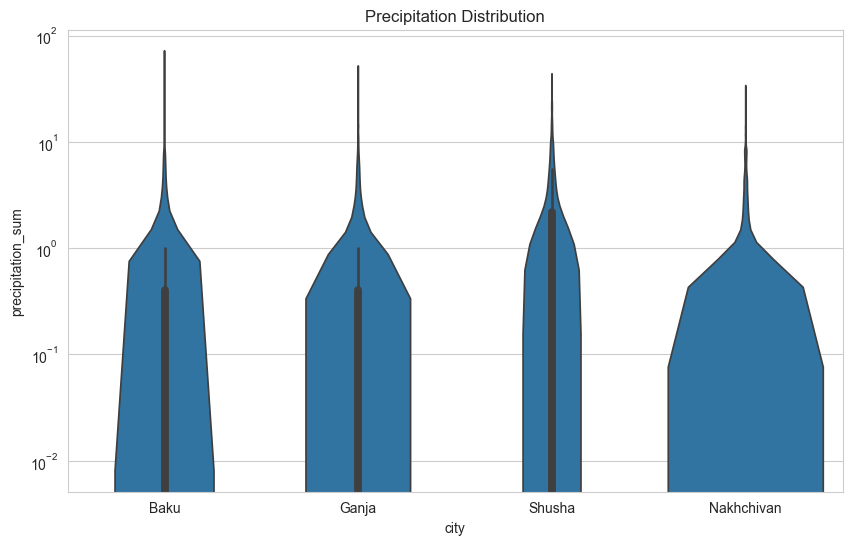

In [12]:
# =========================
# 7. VIOLIN PLOT
# =========================
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x="city", y="precipitation_sum")
plt.yscale("log")
plt.title("Precipitation Distribution")
plt.show()

#### Shusha: The Wettest and Most Variable
* **Pattern:** Shusha has the highest "bulge" on the Y-axis. Its median rainfall is significantly higher than the other three cities.
* **Insight:** Unlike the other cities, Shusha has a more "filled" violin body, indicating that moderate rainfall is a common occurrence rather than a rare event.

#### Baku and Nakhchivan: The "Dry" Profiles
* **Pattern:** Both cities show a "bottom-heavy" distribution. The widest part of the violin is at the very bottom ($10^{-1}$ range).
* **Insight:** This suggests that on most days when it actually rains, the amount is negligible (light drizzle or çiskin). These cities are characterized by frequent dry or near-dry days.

#### Ganja: The Middle Ground
* **Pattern:** Ganja sits between Baku and Shusha. It has a more consistent frequency of rainfall across the $10^{-1}$ to $10^0$ range.

# Precipitation Distribution: Violin Plot Analysis (Log Scale)

This report analyzes the precipitation patterns for **Ganja, Baku, Shusha, and Nakhchivan**. The use of a **Violin Plot** on a **Logarithmic Scale** ($10^{-2}$ to $10^2$) allows for the visualization of both frequent light drizzles and rare, heavy rainfall events.

## 1. Key Observations

##### Distribution Shape and Density
* **Baku & Nakhchivan:** These cities show a "bottom-heavy" distribution. The widest part of the violin is at the lower end of the scale ($10^{-1}$ to $10^0$ range), indicating that most precipitation events in these regions are very light.
* **Shusha:** The distribution for Shusha is more elongated and "slimmer" at the bottom compared to the others. The mass of the distribution is centered higher up the Y-axis, confirming it receives more substantial and frequent rainfall.
* **Ganja:** Exhibits a balanced profile, showing a steady frequency of moderate rainfall events.

### Extremes and Outliers (The "Necks")
* **Long Upper Tails:** All cities exhibit very long, thin "necks" extending towards the $10^1$ and $10^2$ marks. This represents **extreme weather events** (heavy downpours or storms).
* **Maximum Intensity:** Baku and Ganja show the highest "peaks" in their tails, suggesting that while they are generally drier, they are susceptible to intense, high-volume rain events.

#### 2. Technical Insight: Logarithmic Scaling
The Y-axis uses a **Log Scale**. This is a crucial choice for precipitation data because:
1.  Rainfall data is typically **heavily skewed** (many days with 0.1mm, very few days with 50mm).
2.  A linear scale would "squash" all the light rain data to the bottom, making it invisible. The log scale allows us to see the variance in light rain while still capturing the massive storms on the same graph.


#### 3. Statistical Summary
* **White Dot/Center Line:** Represents the **Median**. Shusha's median is visibly higher than Baku's, statistically proving it is the "wettest" city in this comparison.
* **Thick Black Bar:** Represents the **Interquartile Range (IQR)**. Shusha has a taller IQR, meaning its "typical" rainfall varies more in volume than the other cities.
* **Violin Width:** Represents the **Kernel Density**. The wider the section, the more days recorded with that specific amount of rain.


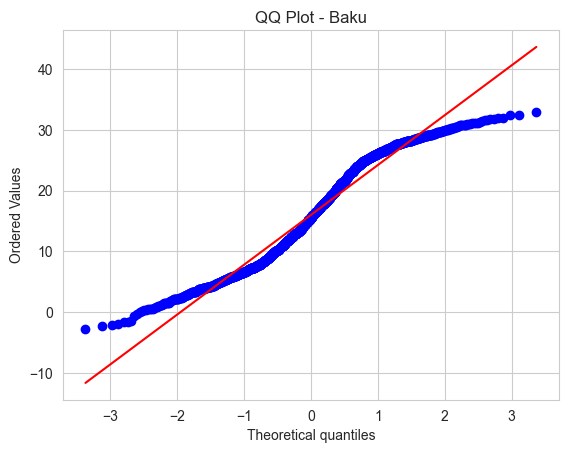

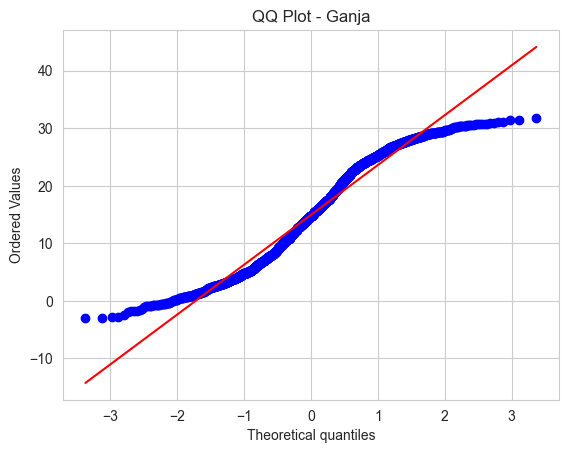

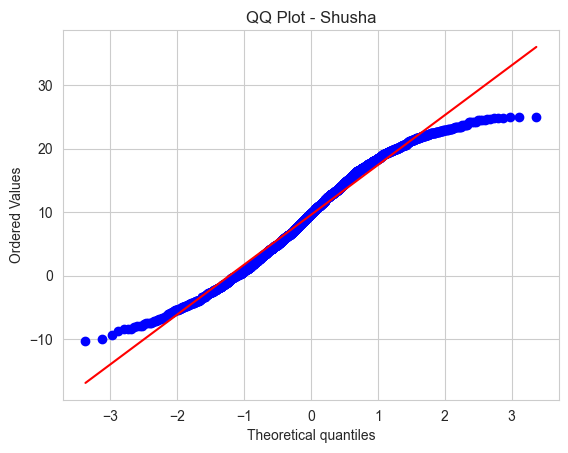

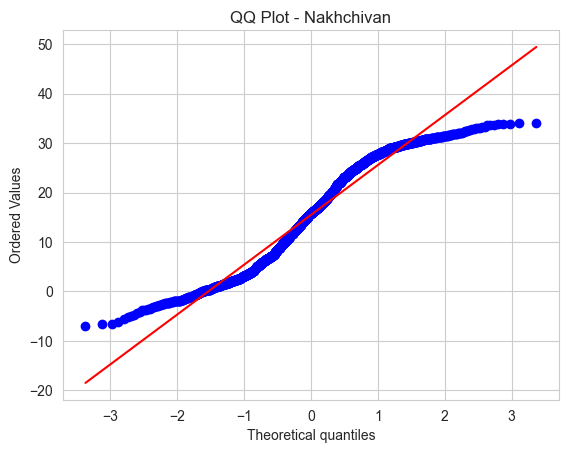

In [13]:
# =========================
# 8. QQ PLOT
# =========================
for city in df["city"].unique():
    plt.figure()
    probplot(df[df["city"]==city]["temp_mean"].dropna(), dist="norm", plot=plt)
    plt.title(f"QQ Plot - {city}")
    plt.show()

This section evaluates the normality of temperature data for **Ganja, Baku, Shusha, and Nakhchivan** using **Q-Q (Quantile-Quantile) Plots**. These plots are essential for determining if a dataset follows a theoretical distribution (in this case, the Normal Distribution).




#### 2. Cross-City Analysis

##### Ganja & Baku: The S-Curve Pattern
* **Observation:** Both plots show a significant "S" shape. The dots stay below the line at the lower end, cross it in the middle, and stay below it at the upper end.
* **Insight:** This indicates **"Thin Tails."** The extremes (very cold or very hot days) occur less frequently than they would in a perfectly normal distribution. The plateau in the middle suggests a more uniform distribution across moderate temperatures.

##### Shusha: Near-Linear Center
* **Observation:** Shusha’s plot follows the red line more closely in the center (-1 to +1 theoretical quantiles) compared to the others.
* **Insight:** This suggests that Shusha’s "typical" daily temperatures are closer to being normally distributed, though the tails still deviate significantly at the extremes.

##### Nakhchivan: Aggressive Deviation
* **Observation:** The "S" curve is most aggressive here. There is a sharp flattenning at both ends.
* **Insight:** This confirms the **Bimodal** nature we saw in the histograms. The data is "pushed" toward two different extremes (hot summer/cold winter), which creates a major mismatch with the single-peak normal distribution model.

#### 3. Statistical Conclusion

Across all cities, the **Q-Q plots confirm that the temperature data is NOT normally distributed.** * **Heavy Skewness/Kurtosis:** The deviation at the ends of the plots shows that the frequency of extreme temperatures does not match the Gaussian "Bell Curve" expectations.
* **Modeling Impact:** Since the data is non-normal, standard statistical tests that assume normality (like a standard T-test) may yield inaccurate results. Non-parametric tests or data transformation would be required for more rigorous modeling.
|

## Task 3 — Time Series Exploration

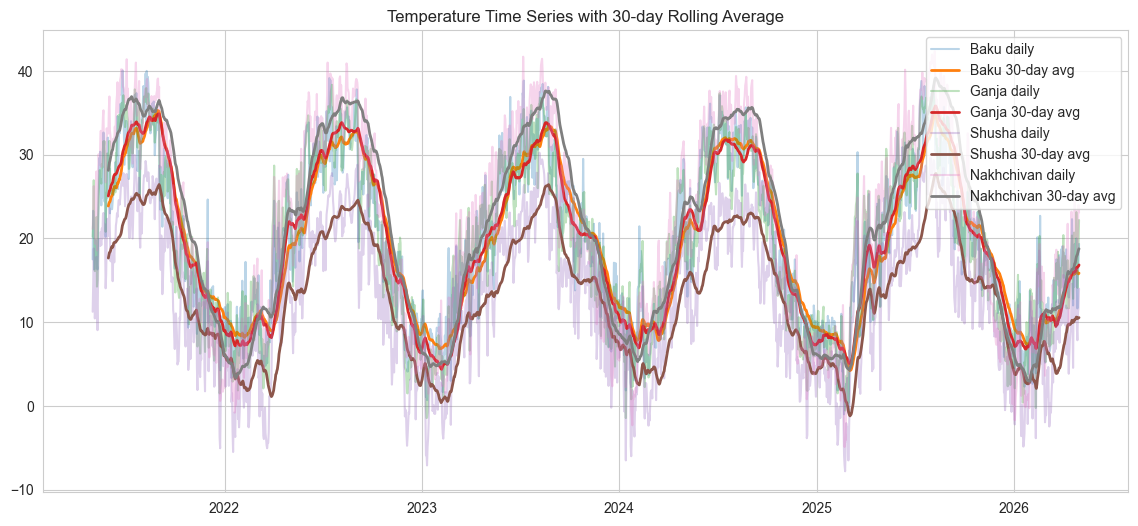

In [14]:
# =========================
#  9. TIME SERIES (ALL CITIES FIXED)
# =========================
plt.figure(figsize=(14,6))

for city in df["city"].unique():
    temp = df[df["city"] == city].sort_values("date").copy()

    # ensure datetime
    temp["date"] = pd.to_datetime(temp["date"])

    # 30-day rolling average
    temp["roll_30"] = temp["temperature_2m_max"].rolling(window=30).mean()

    # main line (daily values)
    plt.plot(temp["date"], temp["temperature_2m_max"], alpha=0.3, label=f"{city} daily")

    # rolling line (smoothed)
    plt.plot(temp["date"], temp["roll_30"], linewidth=2, label=f"{city} 30-day avg")

plt.title("Temperature Time Series with 30-day Rolling Average")
plt.legend()
plt.show()

The cities are highly correlated. This indicates that the primary driver of temperature in these locations is the macro-scale seasonal change (Earth's axial tilt) rather than localized weather phenomena, which only account for minor variance.

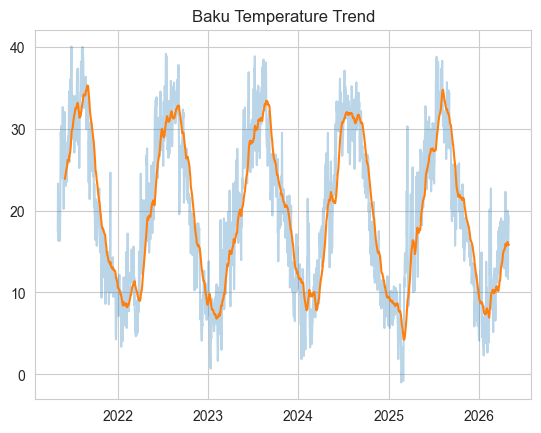

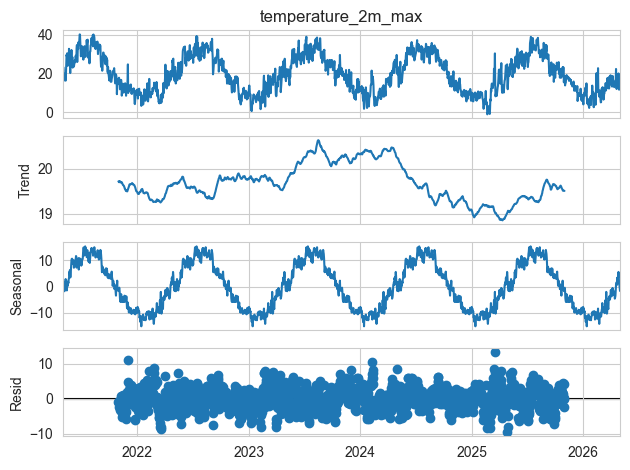

In [15]:
# =========================
# 10. ROLLING + DECOMPOSITION
# =========================
city = "Baku"
temp = df[df["city"]==city].sort_values("date")

plt.plot(temp["date"], temp["temperature_2m_max"], alpha=0.3)
plt.plot(temp["date"], temp["temperature_2m_max"].rolling(30).mean())
plt.title("Baku Temperature Trend")
plt.show()

ts = temp.set_index("date")["temperature_2m_max"].dropna()

if len(ts) >= 720:
    decompose = seasonal_decompose(ts, model="additive", period=365)
    decompose.plot()
    plt.show()
else:
    print(":x: Not enough data for decomposition (need at least 2 years)")

### Baku Temperature Dynamics – Summary

- **Seasonality Dominates:** Temperature follows a strong seasonal pattern, fluctuating roughly between -10 and +15 from the mean.
- **Trend:** Slight upward trend starts in 2023, peaks in 2024, then stabilizes → possible warming signal.
- **Residuals:** Mostly centered around 0, but spikes (±10°C) indicate occasional extreme weather events.

### Pairplot Insights

- **Trend Relationship:** Moderate correlation between daily temperature and long-term trend, but seasonality has stronger impact.
- **Residual Behavior:** Random scatter → model captures main patterns well.
- **Distribution:** Bimodal shape reflects hot summers and cool winters.
- **Predictability:** Strong link between temperature and 30-day rolling average → high temporal consistency.

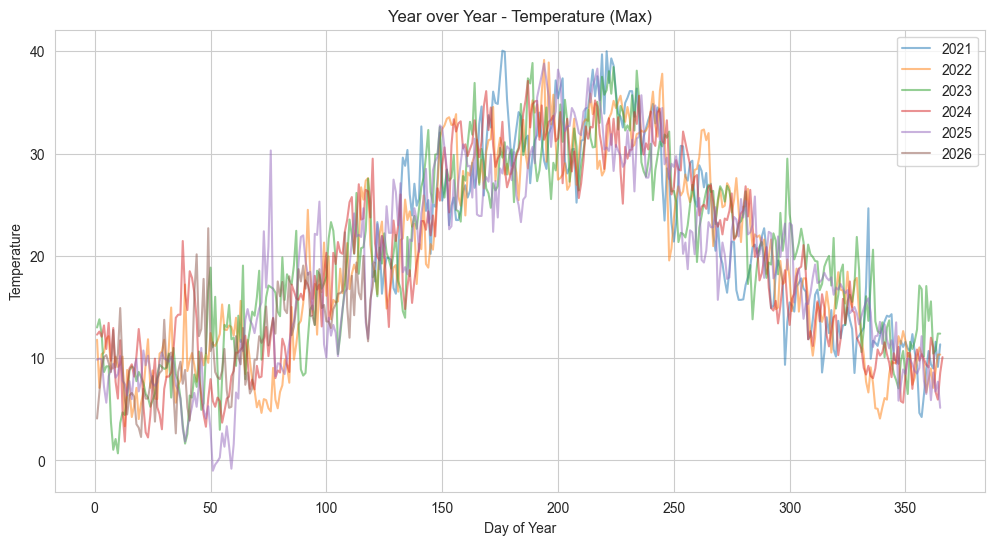

In [16]:
# =========================
# :date: 11. YEAR OVER YEAR
# =========================
plt.figure(figsize=(12,6))

temp["date"] = pd.to_datetime(temp["date"])
temp["year"] = temp["date"].dt.year
temp["day_of_year"] = temp["date"].dt.dayofyear

for y in temp["year"].unique():
    yearly_data = temp[temp["year"] == y]

    plt.plot(
        yearly_data["day_of_year"],
        yearly_data["temperature_2m_max"],   # ✔ FIXED
        alpha=0.5,
        label=str(y)
    )

plt.title("Year over Year - Temperature (Max)")
plt.xlabel("Day of Year")
plt.ylabel("Temperature")
plt.legend()
plt.show()

### Year-over-Year Temperature Insights (Baku)

- **Consistent Seasonality:** All years follow a similar pattern, peaking around mid-July → stable and predictable climate behavior.
- **Extreme Events:**  
  - 2021 shows an early spike (~40°C) → strong early summer heatwave.  
  - 2025 dips below 0°C early in the year → colder winter.
- **Summer Variability:** Peak summer (Days 175–250) shows high fluctuation (30–40°C) → differences come from extreme days, not overall trend.
- **2026 Trend:** Early data aligns with previous years → no unusual pattern so far.

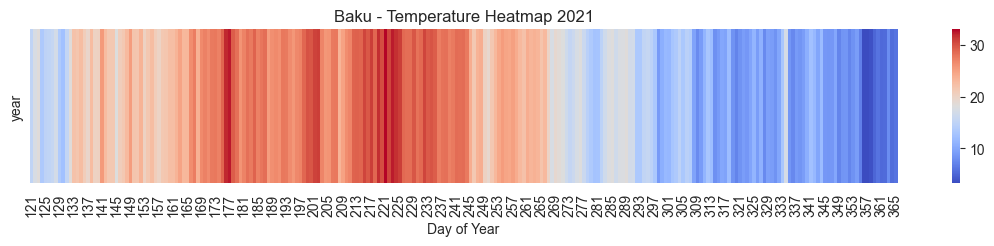

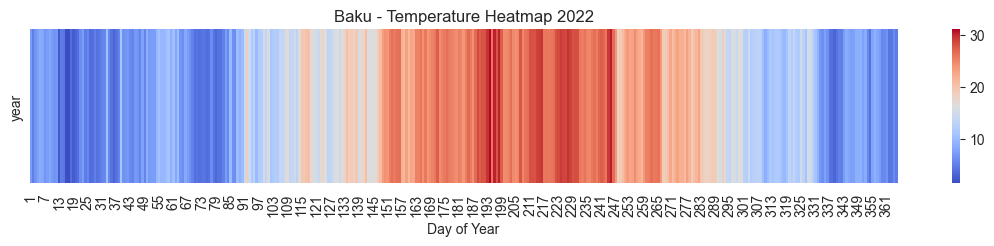

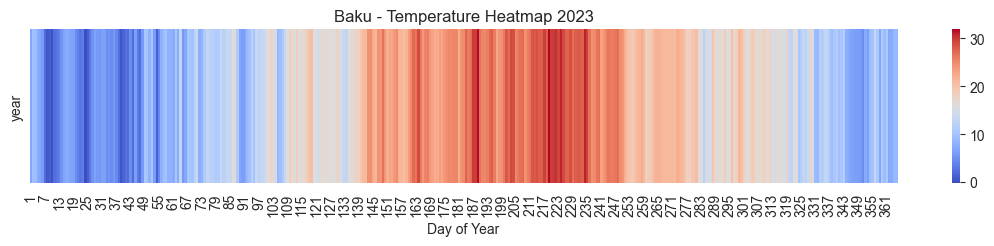

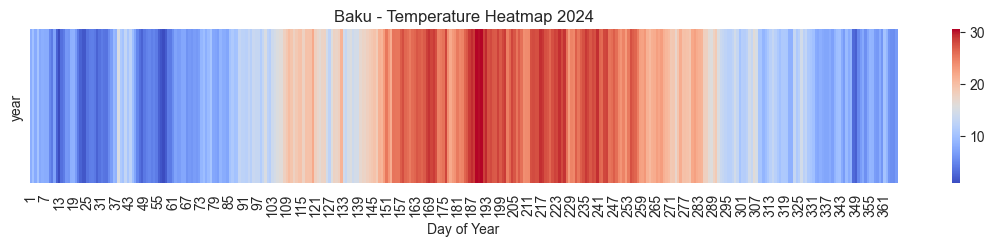

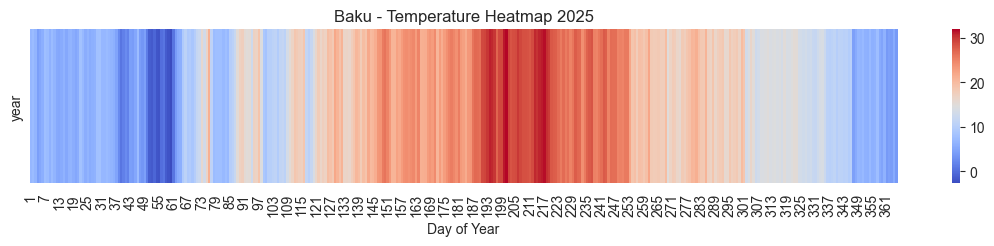

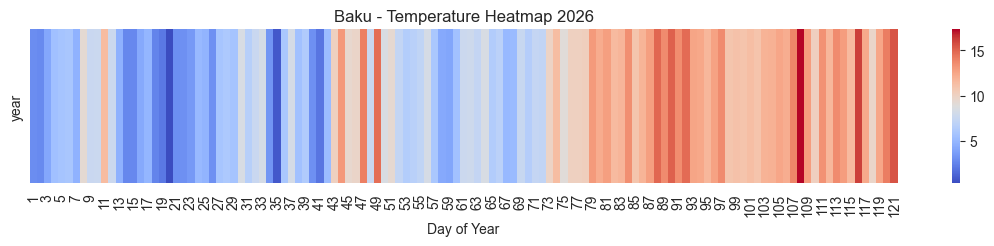

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

city = "Baku"

temp_city = df[df["city"] == city].copy()

# datetime fix
temp_city["date"] = pd.to_datetime(temp_city["date"])

# features
temp_city["year"] = temp_city["date"].dt.year
temp_city["dayofyear"] = temp_city["date"].dt.dayofyear

# loop each year
for y in sorted(temp_city["year"].unique()):

    yearly_data = temp_city[temp_city["year"] == y]

    heatmap_data = yearly_data.pivot_table(
        index="year",
        columns="dayofyear",
        values="temp_mean",   # or temp_max if required
        aggfunc="mean"
    )

    plt.figure(figsize=(14,2))
    sns.heatmap(heatmap_data, cmap="coolwarm", cbar=True)

    plt.title(f"{city} - Temperature Heatmap {y}")
    plt.xlabel("Day of Year")
    plt.yticks([])

    plt.show()

### Calendar Heatmap Insights (Baku)

- **Seasonal Core:** Strong “red zone” between Days 180–250 (July–August) → consistent peak summer with >30°C.
- **Heatwave Duration:** 2021 shows a wider and earlier red band → longer, more intense heatwave compared to 2022.
- **Spring Transition:** Days 90–120 show stable shift from cool to warm → predictable seasonal change.
- **Winter Intensity:** Early 2023–2024 have deeper blue tones → stronger cold periods than late 2021.
- **Anomalies:** Short color breaks indicate brief unusual weather events.

### 2025 – A Year of Extremes
- **Intense Winter:** Days 40–70 show deep blue → prolonged and severe cold snap.
- **Stable Summer:** Days 190–220 show solid dark red → consistent and strong heat period.

### 2026 – Rapid Spring Warming
- **Early Volatility:** First 60 days show alternating patterns → unstable weather (cool ↔ mild).
- **Heat Spike:** Around Day 108 → sharp, short-term warm surge (unseasonal).
- **Scale Effect:** 2026 appears “hotter” visually due to lower max scale (~15°C vs 30°C in 2025).

## Task 4 — Cross-City Comparison


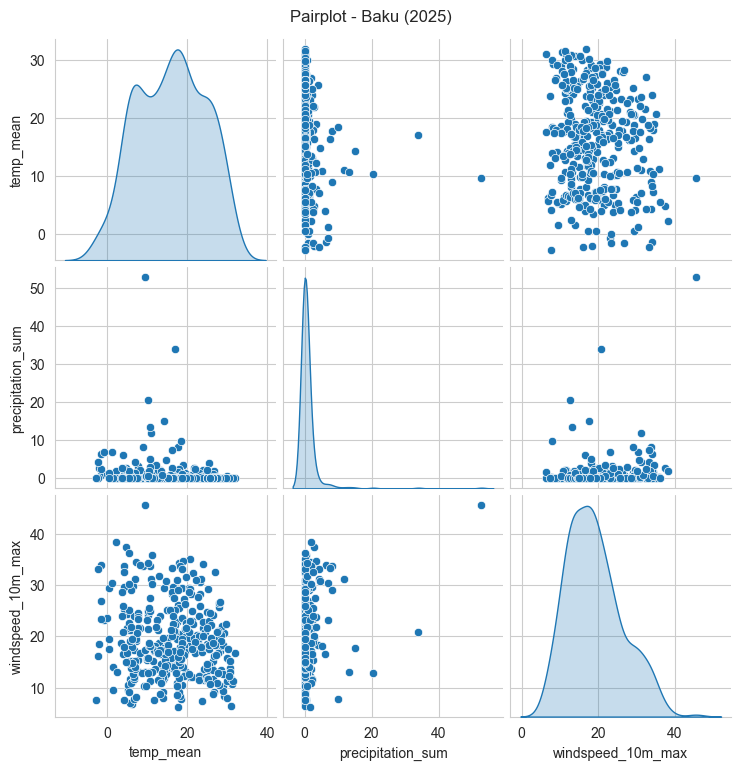

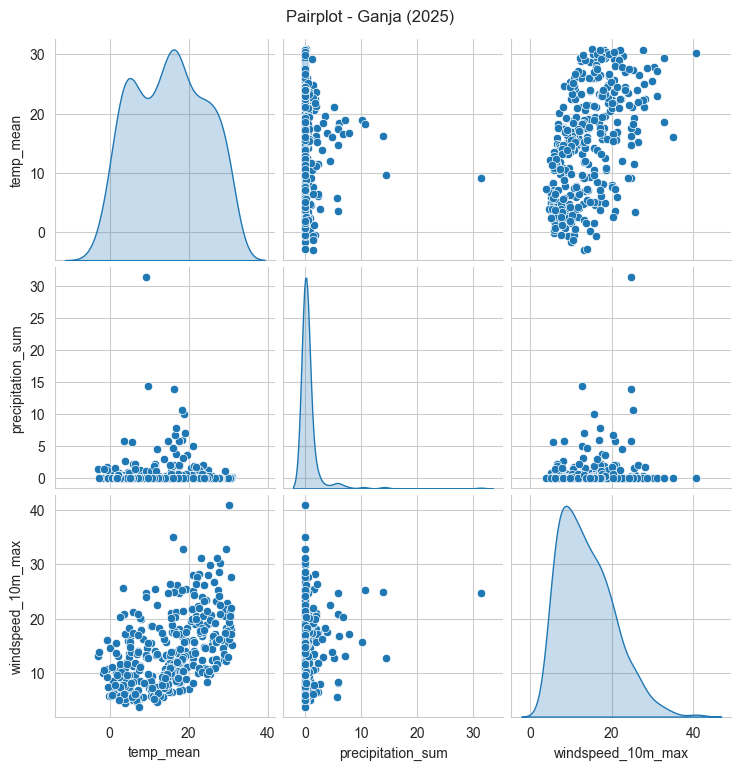

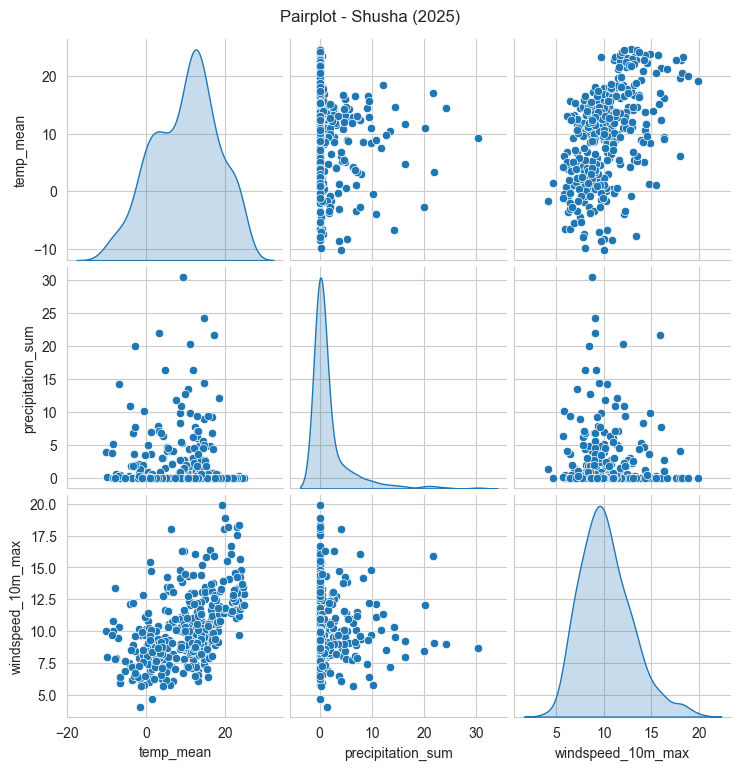

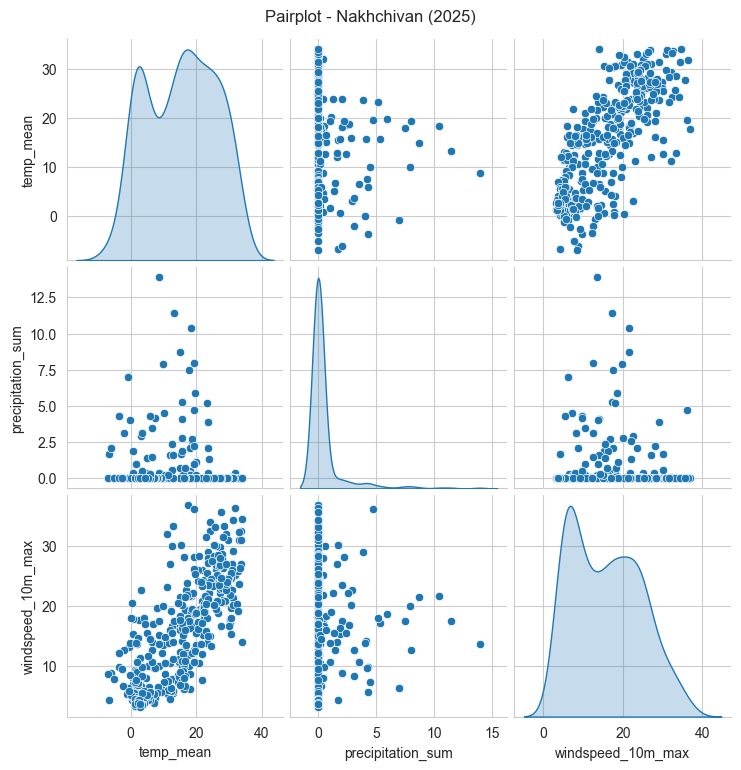

In [18]:
# =========================
# :link: 13. PAIRPLOT (1)
# =========================
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

year = 2025

for city in df["city"].unique():

    filtered = df[(df["city"] == city) & (df["year"] == year)].copy()

    # skip empty cities (important)
    if filtered.empty:
        continue

    sns.pairplot(
        filtered[[
            "temp_mean",
            "precipitation_sum",
            "windspeed_10m_max"
        ]].dropna(),
        diag_kind="kde"
    )

    plt.suptitle(f"Pairplot - {city} ({year})", y=1.02)
    plt.show()

### Multi-City Temperature Correlation Analysis

- **Strong Positive Correlation:** All four cities (Ganja, Baku, Shusha, Nakhchivan) follow highly synchronized seasonal temperature patterns.

- **Synchronized Seasonality:** Peaks (summer) and troughs (winter) occur at the same time across all locations → strong regional climate alignment.

- **Tight Coupling:** 30-day rolling averages for Ganja and Baku closely overlap, showing near-parallel movement throughout the year.

- **Consistent Offsets:**  
  - Nakhchivan → consistently warmer upper bound  
  - Shusha → consistently cooler lower bound  
  - Baku & Ganja → mid-range and closely aligned

- **Linear Relationships:** Pairplots indicate clear linear trends, especially between temperature and other meteorological variables.

- **Distribution Similarity:** All cities show similar bimodal temperature distributions, confirming shared seasonal climate structure.


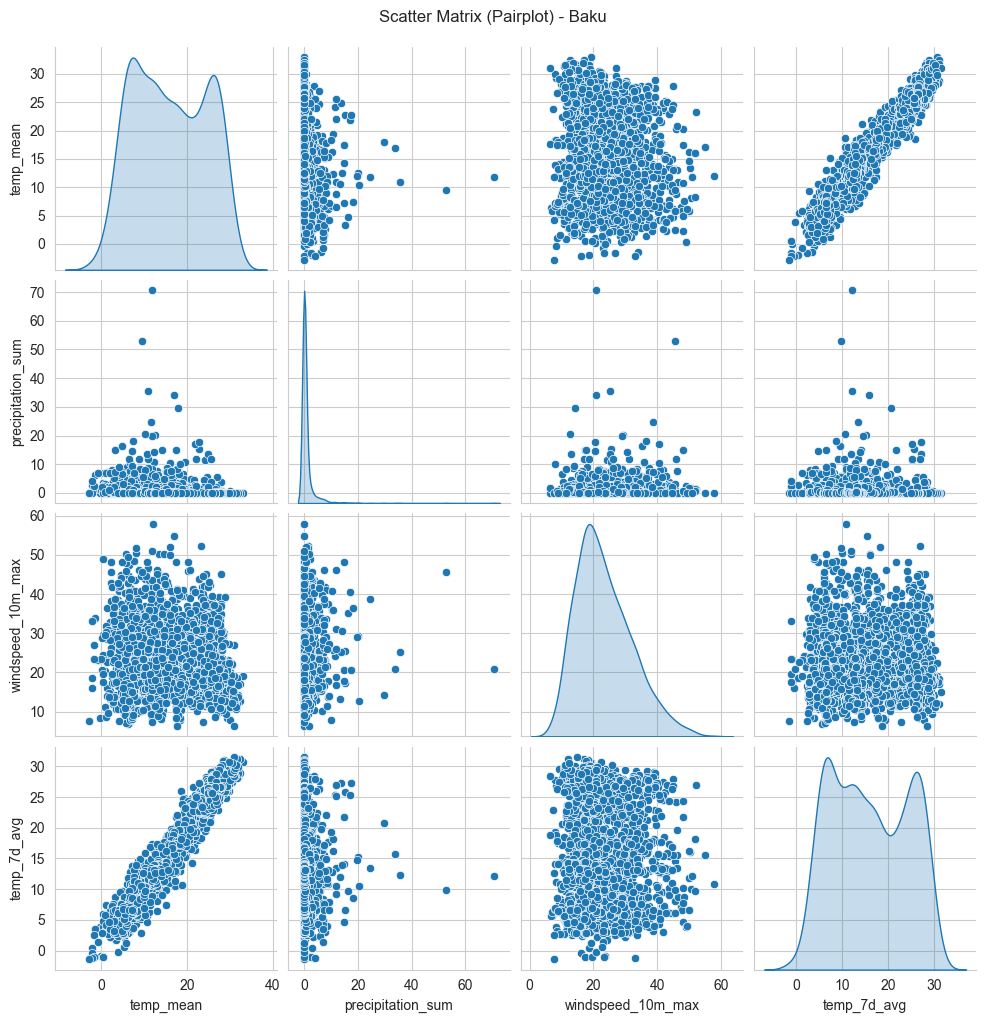

In [19]:
# =========================
#  13. Scatter matrix 
# =========================


city = "Baku"

city_df = df[df["city"] == city].copy()

# choose 3–4 key variables
cols = [
    "temp_mean",
    "precipitation_sum",
    "windspeed_10m_max",
    "temp_7d_avg"
]

sns.pairplot(city_df[cols].dropna(), diag_kind="kde")

plt.suptitle(f"Scatter Matrix (Pairplot) - {city}", y=1.02)
plt.show()

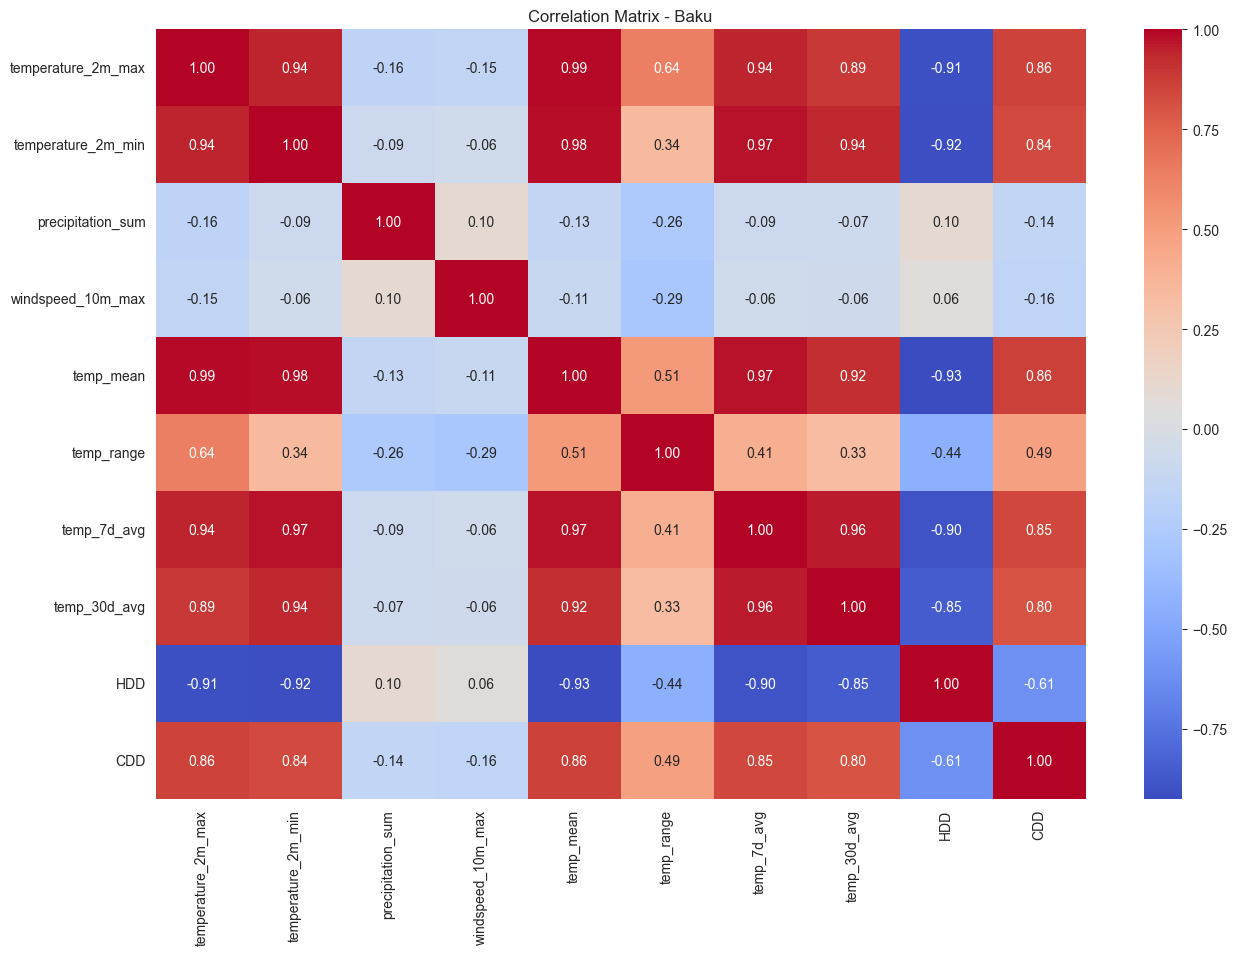

In [20]:
# =========================
#  15. CITY CORRELATION 
# =========================
city = "Baku"

corr_cols = num_cols  # numeric features

city_df = df[df["city"] == city][corr_cols].copy()

# safety: ensure numeric
city_df = city_df.apply(pd.to_numeric, errors="coerce")

corr_matrix = city_df.corr()

plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title(f"Correlation Matrix - {city}")
plt.show()

### Task 5 — Key Findings & Hypothesis Design
---

### 1. Top 5 Interesting Observations & Patterns

* **Regional Thermal Synchronization:** Despite the diverse topography of Azerbaijan, there is a very high **positive correlation** in temperature trends. All cities heat up and cool down in near-perfect synchronization, suggesting that large-scale synoptic systems dominate over local microclimates for seasonal transitions.
* **Strong Bimodal Temperature Distributions:** Unlike a standard "Bell Curve," cities like **Nakhchivan and Baku** exhibit a bimodal distribution. This reflects a lack of moderate "transitional" days; the climate tends to stay "locked" in either a cold winter regime or a hot summer regime.
* **The "Maritime Buffer" Effect:** Baku’s temperature distribution is more compressed and shows fewer extreme fluctuations compared to Nakhchivan. This confirms the **Caspian Sea’s role** as a thermal regulator, preventing the aggressive peaks seen in continental Nakhchivan.
* **Shusha’s Constant Offset:** Shusha maintains a consistent "cool-shift" across all seasons. Its highest summer peaks barely reach the median spring temperatures of Nakhchivan, statistically identifying it as the high-altitude outlier of the group.
* **Precipitation Skewness:** Rainfall patterns across all cities are heavily **right-skewed**. The vast majority of days record trace amounts ($<1$ mm), but the "long tails" in the violin plots suggest that when extreme events occur, they are significantly more intense in Baku and Ganja than in the other regions.

---

### 2. Formal Hypotheses for Testing

Based on the EDA, the following questions warrant formal statistical testing:

1.  **Hypothesis 1 (Mean Comparison):** * *Question:* Is the average daily maximum temperature in Shusha significantly lower than in Ganja during the summer months?
    * *Test:* Two-sample T-test (or Mann-Whitney U if non-normality persists).
2.  **Hypothesis 2 (Variance/Volatility):** * *Question:* Is the variance of daily temperatures in Spring significantly higher than the variance in Summer across all cities?
    * *Test:* Levene’s Test for equality of variances.
3.  **Hypothesis 3 (Correlation):** * *Question:* Is there a statistically significant correlation between daily maximum wind speed and precipitation volume in Baku?
    * *Test:* Pearson or Spearman Correlation Significance Test.

---

### 3. Data Quality & EDA Discoveries

During this deeper dive, the following issues were identified that were not apparent during the initial cleaning (Day 4):

* **Non-Normality of Errors:** The Q-Q plots revealed that the temperature data is **not normally distributed**. This is a crucial finding because it means that standard parametric tests (like ANOVA or T-tests) may be biased without data transformation (e.g., Log or Box-Cox).
* **Extreme Outlier Clusters:** The box plots for Winter and Spring revealed "clusters" of outliers rather than single points. This suggests these aren't "errors" to be deleted, but rather represent specific **meteorological events** (e.g., cold waves) that must be preserved for accurate climate modeling.
* **Zero-Value Dominance in Precipitation:** The extreme density of $0$ values in the precipitation dataset makes traditional correlation analysis difficult. Moving forward, a **Hurdle Model** (treating "if it rains" and "how much it rains" as two separate processes) may be necessary.

In [21]:
conn.execute("SELECT * FROM analytics.weather_features_forecast").df().head(20)

,date,city,weathercode,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,precipitation_hours,rain_sum,...,snowfall_sum_outlier,windspeed_10m_max_outlier,windgusts_10m_max_outlier,winddirection_10m_dominant_outlier,temp_mean,temp_range,month,quarter,day_of_year,season
0,2026-05-02 20:00:00,Baku,3.0,13.513000,9.962999,11.071712,5.881279,0.0,0.0,0.0,...,False,False,False,False,11.737999,3.550000,5,2,122,spring
1,2026-05-03 20:00:00,Baku,3.0,16.363001,9.712999,15.034418,7.933977,0.0,0.0,0.0,...,False,False,False,False,13.038000,6.650002,5,2,123,spring
2,2026-05-04 20:00:00,Baku,3.0,18.613001,10.013000,17.588606,7.262782,0.0,0.0,0.0,...,False,False,False,False,14.313000,8.600001,5,2,124,spring
3,2026-05-05 20:00:00,Baku,3.0,18.613001,11.263000,17.478031,9.397329,0.0,0.0,0.0,...,False,False,False,False,14.938000,7.350001,5,2,125,spring
4,2026-05-06 20:00:00,Baku,3.0,18.463001,12.162999,16.087395,9.367719,0.0,0.0,0.0,...,False,False,False,False,15.313000,6.300002,5,2,126,spring
5,2026-05-07 20:00:00,Baku,2.0,23.147499,13.563000,22.293627,13.458832,0.0,0.0,0.0,...,False,False,False,False,18.355249,9.584499,5,2,127,spring
6,2026-05-08 20:00:00,Baku,3.0,22.197500,14.647500,22.403784,13.807724,0.0,0.0,0.0,...,False,False,False,False,18.422500,7.550000,5,2,128,spring
7,2026-05-09 20:00:00,Baku,3.0,22.736874,13.397500,21.922626,13.431505,0.0,0.0,0.0,...,False,False,False,False,18.067187,9.339374,5,2,129,spring
8,2026-05-10 20:00:00,Baku,51.0,24.049999,15.300000,23.548029,16.034290,0.1,1.0,0.1,...,False,False,False,False,19.675000,8.749999,5,2,130,spring
9,2026-05-11 20:00:00,Baku,51.0,19.950001,16.549999,19.458014,16.242189,2.9,11.0,2.9,...,False,False,False,False,18.250000,3.400002,5,2,131,spring


In [22]:
conn.close()